In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import mediapipe as mp
from keras import layers
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, AdamW
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from mediapipe.tasks.python.vision import face_landmarker


In [2]:
import torch
torch.cuda.is_available()

True

In [6]:
# FaceLandmarker
base_options = python.BaseOptions(model_asset_path='../face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

TRAIN_DATA_PATH = os.path.join("../affectnet_dataset/Train")
TEST_DATA_PATH = os.path.join("../affectnet_dataset/Test")
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)
SAVED_MODEL = "../saved_models/mlp_weighted_model.h5"

keypoints_dir = "../keypoints_affectnet"
os.makedirs(keypoints_dir, exist_ok=True)
data_dirs = {
    "train": TRAIN_DATA_PATH,
    "test": TEST_DATA_PATH
}

In [4]:

def extract_keypoints(results):
    if results.face_landmarks:
        face = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]
        )

        # center
        center = face.mean(axis=0)
        face = face - center

        # scale normalize
        scale = np.linalg.norm(face.max(axis=0) - face.min(axis=0))
        if scale != 0:
            face = face / scale

        return face.flatten()
    else:
        return np.zeros(468 * 3)

In [7]:
for split, split_dir in data_dirs.items():
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        save_class_path = os.path.join(keypoints_dir, split, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):
            if img_name.startswith("."):
                continue

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (75, 75))

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)

            results = detector.detect(mp_image)

            if results.face_landmarks:
                face_landmarks = results.face_landmarks[0]
                keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
            else:
                keypoints = np.zeros((468, 3))

            save_path = os.path.join(
                save_class_path,
                img_name.split('.')[0] + ".npy"
            )
            np.save(save_path, keypoints)

print("Keypoints saved in folder:", keypoints_dir)

Keypoints saved in folder: ../keypoints_affectnet


In [16]:
train_dataset = ImageDataGenerator().flow_from_directory(
    TRAIN_DATA_PATH,
)
train_counts = {}
CLASSES = list(train_dataset.class_indices.keys())

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

Found 16108 images belonging to 8 classes.
{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [7]:
folder = "../keypoints_dataset_2/train/contempt"

# List all .npy files
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(478, 3)


In [8]:
# Load keypoints arrays
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../keypoints_dataset/train")

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# THEN standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

(12886, 1404) (12886, 8)


In [9]:
# Weight parameter in CrossEntropyLoss function to apply a weight to each class based on its frequency
y_labels = np.argmax(y_train, axis=1)
# class weights will be given by
# n_samples / (n_classes * np.bincount(y))
# np.bincount counts the occurrences of value in an input array
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)
weights = dict(zip(np.unique(y_labels), class_weights_array))
print("Class weights array:", weights)

Class weights array: {np.int64(0): np.float64(1.3356135986733002), np.int64(1): np.float64(1.2834661354581673), np.int64(2): np.float64(1.6588568486096806), np.int64(3): np.float64(1.3170482420278005), np.int64(4): np.float64(0.8636729222520108), np.int64(5): np.float64(0.7338268792710706), np.int64(6): np.float64(0.6466278602970694), np.int64(7): np.float64(0.9587797619047619)}


In [ ]:
model = tf.keras.Sequential([
    layers.Input(shape=(1404,)),
    
    # Block 1
    layers.Dense(1024, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.2),

    layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(8, activation='softmax')
])

model.compile(optimizer=AdamW(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       719,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 895,944 (3.42 MB)

 Trainable params: 894,152 (3.41 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,    
    min_lr=1e-6
)
csv_logger = CSVLogger('../logs/mlp_weighted_loss_training_log.csv')

In [12]:
import time
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=weights,
    callbacks=[es, mc, csv_logger]
)
end = time.time()

print("Training time: ", (end - start)/60)

Epoch 1/50
395/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2236 - loss: 2.1930

403/403 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2752 - loss: 2.0614 - val_accuracy: 0.3845 - val_loss: 1.7775
Epoch 2/50
396/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3449 - loss: 1.8844

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3487 - loss: 1.8827 - val_accuracy: 0.4212 - val_loss: 1.7058
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3705 - loss: 1.8224

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3713 - loss: 1.8184 - val_accuracy: 0.4336 - val_loss: 1.6537
Epoch 4/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3941 - loss: 1.7801

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3844 - loss: 1.7901 - val_accuracy: 0.4463 - val_loss: 1.6298
Epoch 5/50
402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3809 - loss: 1.7832

...

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4028 - loss: 1.7229 - val_accuracy: 0.4600 - val_loss: 1.5792
Epoch 9/50
395/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4056 - loss: 1.7186

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3997 - loss: 1.7201 - val_accuracy: 0.4606 - val_loss: 1.5778
Epoch 10/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4020 - loss: 1.7106 - val_accuracy: 0.4572 - val_loss: 1.5868
Epoch 11/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4035 - loss: 1.7117 - val_accuracy: 0.4593 - val_loss: 1.5786
Epoch 12/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4064 - loss: 1.7031 - val_accuracy: 0.4544 - val_loss: 1.5763
Epoch 13/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4090 - loss: 1.6980 - val_accuracy: 0.4587 - val_loss: 1.5827
Epoch 14/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4118 - loss: 1.7023 - val_accuracy: 0.4534 - val_loss: 1.5608
Epoch 15/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4111 - loss: 1.6946 - val_accuracy: 0.4382 - val_loss: 1.5892
Epoch 16/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4064 - loss: 1.7037 - val_accuracy: 0.4472

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4092 - loss: 1.6974 - val_accuracy: 0.4628 - val_loss: 1.5624
Epoch 20/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4199 - loss: 1.6887 - val_accuracy: 0.4565 - val_loss: 1.5679
Epoch 21/50
398/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4081 - loss: 1.6832

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4148 - loss: 1.6849 - val_accuracy: 0.4702 - val_loss: 1.5688
Epoch 22/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4164 - loss: 1.6868 - val_accuracy: 0.4559 - val_loss: 1.5721
Epoch 23/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4163 - loss: 1.6872 - val_accuracy: 0.4575 - val_loss: 1.5538
Epoch 24/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4149 - loss: 1.6820 - val_accuracy: 0.4628 - val_loss: 1.5597
Epoch 25/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4176 - loss: 1.6967

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4193 - loss: 1.6784 - val_accuracy: 0.4752 - val_loss: 1.5402
Epoch 26/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4163 - loss: 1.6813 - val_accuracy: 0.4718 - val_loss: 1.5394
Epoch 27/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4185 - loss: 1.6772 - val_accuracy: 0.4637 - val_loss: 1.5557
Epoch 28/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4197 - loss: 1.6680 - val_accuracy: 0.4593 - val_loss: 1.5553
Epoch 29/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4233 - loss: 1.6661 - val_accuracy: 0.4674 - val_loss: 1.5537
Epoch 30/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4201 - loss: 1.6722 - val_accuracy: 0.4708 - val_loss: 1.5425
Epoch 31/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4234 - loss: 1.6678 - val_accuracy: 0.4628 - val_loss: 1.5466
Epoch 32/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4195 - loss: 1.6778 - val_accuracy: 0.4665

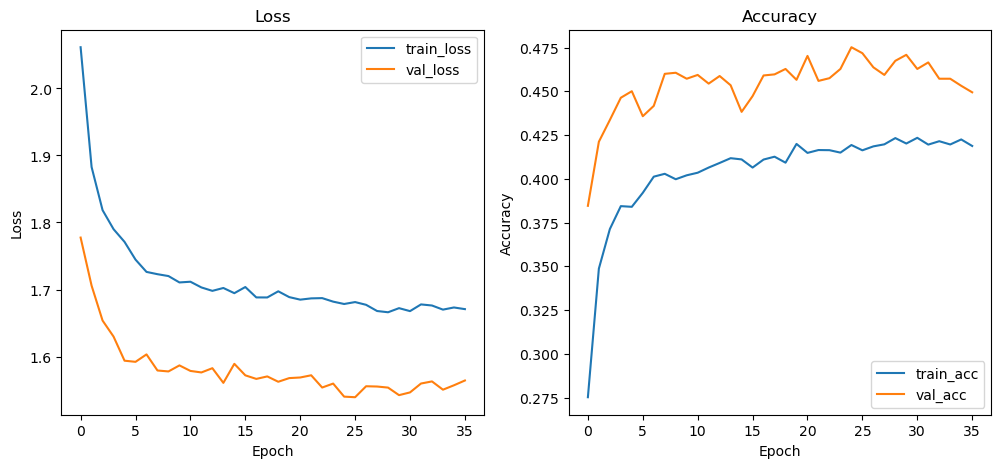

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [14]:
model = load_model(SAVED_MODEL)

In [15]:
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

# load test data
X_test, y_test = load_keypoints_dataset("../keypoints_dataset/test")

# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_cat shape:", y_test_cat.shape)

X_test shape: (14518, 1404)
y_test_cat shape: (14518, 8)


In [16]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = np.argmax(y_test_cat, axis=1)  # one-hot

454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [17]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(ytrue, yhat)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 47.99%


In [23]:
features = StandardScaler().fit_transform(keypoints)
labels = keypoint_labels = train_dataset.classes


print(features.shape)
print(labels.shape)

(478, 3)
(16108,)
